<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

# Intro to AI Agents<a class="tocSkip">

In this notebook we will see how to build **AI Agents** via the `LangGraph` library.

> _You define a graph of nodes (steps), connect them with edges that describe control flow, and let the graph manage state as it moves between tools, LLM calls, and decision points._

The focus is on making Agent behavior explicit and testable (_as opposed to a single LLM prompt_).

**Study case:** We will build an Agent that answers scientific questions — deciding on its own whether to reply directly or invoke a web search tool to retrieve relevant arXiv papers first.

# Setup

In [1]:
#!pip install --quiet -U ipywidgets==8.1.8 langchain_nvidia_ai_endpoints arxiv python-dotenv huggingface_hub transformers accelerate langchain_openai langchain_core langgraph langgraph-prebuilt

In [2]:
import requests

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/colab/clone_and_cd_colab.py"
colab = requests.get(url).text
exec(colab)

Running locally, skipping Colab setup.


In [3]:
import requests

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/styles/plot_style.py"
style = requests.get(url).text
exec(style)

Imported matplotlib.
Imported seaborn.
Plotting style set.


# Using an LLM

## How an LLM generates text

An LLM does not "know" the answer — it **samples** it, one token at a time.

At each step, the model **samples** the next token from a **probability distribution** over its vocabulary:

<img src="images/fig0_distribution.png" width=580 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=580><center><br>
Figure 1. Example next-token distribution over a toy astronomy vocabulary.
The model assigns a distinct probability to every candidate token; the next word is sampled from this distribution.
<br></center></td></tr></table>

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a;">

Formally, at each step $t$ the model computes:

$$P(x_t \mid x_1, \dots, x_{t-1}, \text{prompt})$$

i.e., a probability for **every token in the vocabulary**, conditioned on:
- the **prompt**, and
- all the **tokens generated so far**.

</div>

The **temperature** ($T)$ is a _hyperparameter_ of the model, and reshapes the distribution before sampling:
- **Low $T$** $\rightarrow$ peaked distribution $\rightarrow$ the model almost always picks the highest-probability token (_deterministic_)
- **High $T$** $\rightarrow$ flat distribution $\rightarrow$ lower-probability tokens get more chances (_creative, but less reliable_)

<img src="images/fig1_temperature.png" width=800 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=800><center><br>
Figure 2. Token probability distributions for a toy astronomy vocabulary at three temperatures.
At low $T$ the model concentrates mass on the top token; at high $T$ the distribution flattens and less likely tokens become reachable.
<br></center></td></tr></table>


<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a;">

<details>

<b><summary>[How T is used in the computation] (click here to expand)</summary></b>  

The model produces a vector of **logits** $z_i$ — one per vocabulary token.<br>
These are converted to probabilities via the **softmax** function:

$$p_i = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}$$

where $T$ is the **temperature** — a parameter you control.<br>
The next token is then sampled from this distribution.

</details>
</div>

For **Agents** we want _deterministic_, _reproducible_ behavior, not creative variation $\rightarrow$ We will use $T = 0$.

## Local model vs. API

There are two ways to use a language model from Python:
- **run it locally** on your machine, or
- **call a remote API** where the model runs on someone else's server.

| | Local model | API |
|---|---|---|
| **Cost** | Free after download | Pay per token |
| **Privacy** | Data stays on your machine | Data sent to a third party |
| **Setup** | Heavier (~4–14 GB download) + GPU | Just an API key |
| **Speed** | Depends on your hardware | Fast, always-on |

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">

**NOTE:** In the Agent section we will use an NVIDIA LLM for simplicity, but the interface is identical for a local model.

</div>

## Calling a local model — Mistral

**<u>Load the model</u>**

We load **Mistral-7B-Instruct** locally with `transformers`. The weights download from HuggingFace on first use and are cached afterwards.

In [4]:
import torch
print('CUDA available?', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

CUDA available? True
GPU: NVIDIA GeForce RTX 4090 Laptop GPU


In [5]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL = "mistralai/Mistral-7B-Instruct-v0.2"

model = AutoModelForCausalLM.from_pretrained(
    MODEL,
    device_map="auto",
    dtype=torch.bfloat16,
    attn_implementation="sdpa",
)

"""bfloat16 fits the 7B model in memory: the weights occupy ~14 GB instead of
~28 GB in float32, so the whole model lands on the GPU. In float32 it would not
fit, and device_map='auto' would offload layers to CPU — slowing inference by
1-2 orders of magnitude.

SDPA (Scaled Dot Product Attention) uses PyTorch's built-in optimized attention
backend to use efficient GPU attention kernels when the installed PyTorch/CUDA
stack supports them.""";

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

**<u>Build the prompt</u>**

We turn the role-tagged messages into the exact prompt format Mistral expects using the tokenizer's **chat template**, then tokenize it.

In [6]:
system = "You are a helpful astrophysics assistant."
user = "Explain how to constrain compact dark matter with time-varying quasar equivalent widths."

messages = [
    {"role": "system", "content": system},
    {"role": "user", "content": user},
]

In [7]:
tok = AutoTokenizer.from_pretrained(MODEL)

inputs = tok.apply_chat_template(messages, add_generation_prompt=True, return_tensors="pt").to(model.device)
"""apply_chat_template renders the role-tagged messages into the exact
[INST] ... [/INST] string Mistral was trained on, then tokenizes it.
- add_generation_prompt=True appends the opening that cues the model to start its reply.
- return_tensors="pt" gives PyTorch tensors;""";

inputs = inputs["input_ids"]
print('Number of input tokens:', inputs.shape[0])

Number of input tokens: 1


In [8]:
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

model.generation_config.pad_token_id = tok.pad_token_id

attention_mask = torch.ones_like(inputs)

out = model.generate(
    input_ids=inputs,
    attention_mask=attention_mask,
    max_new_tokens=60,
    do_sample=False,
)
"""Generate a deterministic continuation.

- pad_token sets a valid tokenizer padding token when the model has none.
- generation_config.pad_token_id prevents generate() from inferring the pad token at runtime.
- attention_mask marks all prompt tokens as real tokens, since this example has no padding.
- do_sample=False uses greedy decoding, so the same prompt gives the same output."""

answer_ids = out[0, inputs.shape[1]:]   # keep only the newly generated tokens, not the prompt
print(tok.decode(answer_ids, skip_special_tokens=True).strip())

Compact dark matter (CDM) is a theoretical form of dark matter that is composed of objects with masses ranging from solar mass to planetary mass. One way to search for CDM is by looking for its potential impact on the environment around active galactic nuclei (AGNs), specifically qu


## Calling a remote model via API — NVIDIA

**<u>Setting the API key</u>**

The **API key** is a secret string that identifies and authenticates you to a remote service.

For good manners, API keys shall <u>not</u> be part of the code.<br>
One way is to "hide" them in a `.env` file, then load them from there.

> _After obtaining the NVIDIA key, place it in a `.env` file in the same folder as this notebook._

Example content of the `.env` file:

```python
NVIDIA_API_KEY="<your_nvidia_api_key_here>"
```

then load it with:

```python
from dotenv import load_dotenv
load_dotenv()
```

The key is now stored in the system variable:

```python
os.environ["NVIDIA_API_KEY"]
```

In [9]:
import os
from dotenv import load_dotenv

load_dotenv()  # loads .env if present, skips if key already in system env

NVIDIA_API_KEY = os.getenv("NVIDIA_API_KEY")

if not NVIDIA_API_KEY:
    print("NVIDIA_API_KEY not found in env.")
else:
    print("NVIDIA_API_KEY has been set.")    

NVIDIA_API_KEY has been set.


On **Colab**, use the Secrets manager instead (_left sidebar → 🔑 icon_): add a secret named `OPENAI_API_KEY`, then load it with:

```python
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
```

**<u>Run the model</u>**

The `langchain_nvidia_ai_endpoints` library sends your prompt to NVIDIA's servers and returns the response.

In [10]:
%%time
import os
from langchain_nvidia_ai_endpoints import ChatNVIDIA

llm = ChatNVIDIA(
    model="mistralai/ministral-14b-instruct-2512",
    temperature=0,
    max_completion_tokens=512,
)

response = llm.invoke("Explain how to constrain compact dark matter with time-varying quasar equivalent widths.")
print(response.content)

Constraining **compact dark matter (CDM)**—such as **primordial black holes (PBHs)** or **dark matter axion stars**—using **time-varying quasar equivalent widths (EWs)** is an emerging and promising method. The idea relies on the fact that if CDM objects pass through the line of sight to a quasar, they can **gravitationally lens** or **absorb** light, causing transient changes in the quasar spectrum. One observable signature is a **temporary broadening or suppression of quasar emission lines**, which can be quantified via **equivalent width (EW) variations**.

Here’s a step-by-step explanation of how this method works and how it can constrain CDM:

---

### **1. Physical Mechanism: CDM-Induced Quasar EW Variations**
Quasars emit broad emission lines (e.g., **Lyα, C IV, Mg II**) due to photoionized gas in their broad-line regions (BLRs). If a **compact CDM object** (e.g., a PBH or axion star) passes between the quasar and Earth, it can:
- **Gravitationally lens** the quasar light, causi

<b>Observations</b>

- The `temperature` parameter allows to set how **deterministic** we want the LLM to be<br>

    &emsp;&emsp; **lower** temperature $\leftrightarrow$ more **deterministic**

    &emsp;&emsp; **higher** temperature [max=1] $\leftrightarrow$ more **stochastic**

    Usually, in an Agent framework, we wish to have low temperature since we need a more systematic behavior

- Notice that `llm` is a `langchain_nvidia_ai_endpoints` object.

    This has several methods we will need later, such as:
    ```python
    llm.bind_tools()
    ```

# Tools

Set up the `arXiv` search tool in the form of a <u>function</u> $\rightarrow$ this is what `LangGraph` expects.

[[arXiv search docs](https://info.arxiv.org/help/api/user-manual.html)]

In [11]:
import arxiv
import json

def search_arxiv(query: str, field: str = "all", exact: bool = False,
                 max_results: int = 5, include_abstract: bool = False,
) -> str:
    """Query arXiv and format results as JSON.

    Parameters
    ----------
    query : str
        Search expression passed to arXiv.
    max_results : int, default=5
        Maximum number of results to fetch and format.
    include_abstract : bool, default=False
        If True, include each paper's abstract.
    field : str or None, default="all"
        arXiv search field:
        - ``"ti"``  : title
        - ``"abs"`` : abstract
        - ``"au"``  : author
        - ``"cat"`` : category
        - ``"all"`` : all searchable metadata fields
        - ``None``  : pass the query unchanged to arXiv
    exact : bool, default=False
        If True and ``field`` is not None, wrap the query in double quotes,
        producing a fielded phrase search such as ``ti:"query"``.
        If False and ``field`` is not None, produce a fielded non-phrase
        search such as ``ti:query``. Ignored when ``field`` is None.

    Returns
    -------
    str
        JSON-formatted string containing a list of result objects. Each object
        contains title, link, publication date, and abstract. If no results are
        returned, the JSON list is empty.
    """

    if field is None:
        search_query = query
    elif exact:
        search_query = f'{field}:"{query}"'
    else:
        search_query = f'{field}:{query}'
        
    search = arxiv.Search(
        query=search_query,
        max_results=max_results,
        sort_by=arxiv.SortCriterion.Relevance,
    )

    client = arxiv.Client()
    entries = []

    for result in client.results(search):
        title     = (result.title or "").replace("\n", " ").strip()
        link      = getattr(result, "entry_id", "") or getattr(result, "pdf_url", "")
        abstract  = (getattr(result, "summary", "") or "").replace("\n", " ").strip()
        published = str(getattr(result, "published", "") or "").replace("\n", " ").strip()

        if include_abstract and abstract:
            entries.append({
                "title": title,
                "link": link,
                "published": published,
                "abstract": abstract,
            })
        else:
            entries.append({
                "title": title,
                "link": link,
                "published": published,
                "abstract": "",
            })

    return json.dumps(entries, indent=2)

We could use the tool **as it is**.


In [23]:
result = search_arxiv(query="Constraining compact dark matter with time-varying quasar equivalent widths",
    field=None, exact=False, max_results=1, include_abstract=True)

print(result, "\n")


[
  {
    "title": "The Dark Energy Survey",
    "link": "http://arxiv.org/abs/astro-ph/0510346v1",
    "published": "2005-10-12 13:33:59+00:00",
    "abstract": "We describe the Dark Energy Survey (DES), a proposed optical-near infrared survey of 5000 sq. deg of the South Galactic Cap to ~24th magnitude in SDSS griz, that would use a new 3 sq. deg CCD camera to be mounted on the Blanco 4-m telescope at Cerro Telolo Inter-American Observatory (CTIO). The survey data will allow us to measure the dark energy and dark matter densities and the dark energy equation of state through four independent methods: galaxy clusters, weak gravitational lensing tomography, galaxy angular clustering, and supernova distances. These methods are doubly complementary: they constrain different combinations of cosmological model parameters and are subject to different systematic errors. By deriving the four sets of measurements from the same data set with a common analysis framework, we will obtain important


However, this function has **several parameters** we may setup.

We want to keep it simple for the LLM by only passing the `query` $\rightarrow$ we **wrap** the tool into another function.

We set our parameter choice inside that:
- `max_results=5`
- `field=None`
- `exact=False`
- `include_abstract=True`

In [24]:
# Tool wrapper for the agent
def arxiv_tool(query: str) -> str:
    """Search arXiv for `query` and return formatted top results.

    Parameters
    ----------
    query : str
        Search expression passed to arXiv.

    Returns
    -------
    str
        JSON-formatted string containing up to three arXiv result objects.
        Each object has the following fields:

        - ``"title"`` : paper title
        - ``"link"`` : arXiv entry URL, or PDF URL if the entry URL is unavailable
        - ``"published"`` : publication date as a string
        - ``"abstract"`` : paper abstract
    """
    
    return search_arxiv(query, field=None, exact=False, max_results=3, include_abstract=True)

This function now only requires `query` as input.

IMPORTANT: The docstring of this tool is **what** the Agent will see — be clear on what it does!

### Connect tools to LLM

First of all, `LangGraph` wants the tools in a list, even when we have only 1, like in this case:

In [25]:
# list of tools
tools = [arxiv_tool]

To connect the tools to the LLM, we use the method `.bind_tools()`.

This will modify the `llm` object, and inform it that it has some tools available.

In [26]:
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)
'''About the `parallel_tool_calls`:
    - If False: at most one tool call at a time, then it waits for the result.
    - If True: it may call multiple tools in parallel in a single response.

Selecting False makes the tool calls be sequential. In this case it does not
really matter as we only have 1 tool.''';

/media/work/software/miniconda3/envs/astrostat-7/lib/python3.13/site-packages/langchain_nvidia_ai_endpoints/chat_models.py:1044: UserWarning: Model 'mistralai/ministral-14b-instruct-2512' is not known to support tools. Your tool binding may fail at inference time.
  warnings.warn(


We need one more wrapping: `LangGraph` expects a function that returns a graph state $\rightarrow$ we define an `assistant` function.

> _We will see what "graph state" means later $\rightarrow$ For now consider that, in our example, the "state" is just ... messages:_<br>
> &emsp;&emsp;&emsp; _state = message history_

In [27]:
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage

def assistant(state: MessagesState):
    """Return the next graph state for the assistant node.

    LangGraph expects each node to be a function that accepts and returns
    a graph state. In this tutorial the state is just the conversation
    history: a list of messages representing the user -> assistant loop.
    The assistant wraps the LLM call and returns the updated messages.
    """

    # System prompt: the prior instruction to the model
    # (at inference time, it will take the user input as additional prompt)    
    sys_msg = SystemMessage(content=
        'You are an assistant specialized in astrophysics.' \
        'You may call the arXiv search tool when helpful and should otherwise' \
        'answer directly.')
    
    '''Here, we are providing the LLM with its main context.
       We are instructing it on:
        - its role
        - the fact that it can use tools <-- important!
    '''

    # Run the model and return the next assistant message.
    return {'messages': [llm_with_tools.invoke([sys_msg] + state['messages'])]}

    '''The returned dict IS the next graph state.
        
        The list concatenation
            `[sys_msg] + state['messages']`
        rebuilds the prompt each loop by prepending the system instruction once
        and then appending the accumulated user/assistant/tool messages from
        prior turns.
        The system message is not stored in state; only the conversation
        grows across loops.
    '''

# Build the Agent

We will now **assemble** the Agent using the components we defined.

We will create as a **graph**, so we have to think it in terms of:
- **nodes** (_functions_), and
- **edges** (_connections between functions_).

These act on the graph, which has a **state**.

_Hint: To better understand, look at the resulting figure to grasp the resulting structure, then inverse-engineer the code._

<hr style="height:0.5px; border:none; color:lightgray; background-color:lightgray;">

Let's begin by defining the graph state, then add nodes and edges:

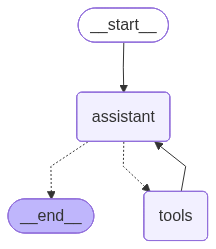

In [28]:
from langgraph.graph import MessagesState, START, StateGraph
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image, display

# Instantiate the graph (we care about states as messages, so we inform LangGraph about it)
builder = StateGraph(MessagesState)

# We add the assistant and tools nodes, and give them a label
builder.add_node('assistant', assistant)
builder.add_node('tools', ToolNode(tools))

# Join the nodes using edges
builder.add_edge(START, 'assistant')  # the entry node is always the special one: 'START', and from there to node 'assistant'
builder.add_conditional_edges("assistant", tools_condition)  # this edge is conditional
'''^Here, `tools_condition` is a special prebuild node --- If the latest message (result) from assistant:
    - is a tool call         -> tools_condition routes to 'tools'
    - is a _not _a tool call -> tools_condition routes to 'END'
'''
builder.add_edge('tools', 'assistant')  # additional edge that always sends _back_ from 'tools' to 'assistant', for a re-evaluation

# Actual build
article_graph = builder.compile()

# Show the compiled graph as a mermaid PNG
display(Image(article_graph.get_graph(xray=True).draw_mermaid_png()))

# Execute Agent

In [29]:
%%time
# Here we place our task to the Agent in natural language
user_prompt = (
    "Explain how to constrain compact dark matter with time-varying quasar equivalent widths.\n"
    "If you are unsure, look for papers more recent than 2023.\n"
    "Respond combining the information you collected from the abstracts you retrieved.\n"
)

# Convert from string to a LangGraph message
user_messages = [HumanMessage(content=user_prompt)]

# Actual agent invocation: this executes the graph
response_messages = article_graph.invoke({'messages': user_messages})

# Check the sequence of performed actions
for m in response_messages['messages']:
    try:
        m.pretty_print()
    except Exception:
        print(str(m))

================================ Human Message =================================

Explain how to constrain compact dark matter with time-varying quasar equivalent widths.
If you are unsure, look for papers more recent than 2023.
Respond combining the information you collected from the abstracts you retrieved.

================================== Ai Message ==================================
Tool Calls:
  arxiv_tool (chatcmpl-tool-bfe065cc76cdd680)
 Call ID: chatcmpl-tool-bfe065cc76cdd680
  Args:
    query: compact dark matter quasar equivalent widths constraints
================================= Tool Message =================================
Name: arxiv_tool

[
  {
    "title": "Possible Couplings of Dark Matter",
    "link": "http://arxiv.org/abs/1809.09971v1",
    "published": "2018-09-24 19:05:16+00:00",
    "abstract": "Dark matter interacts gravitationally, but it presumably interacts weakly through other channels, especially with respect to regular luminous matter. We look at diff

In [19]:
###EOF